In [1]:
from dotenv import load_dotenv

load_dotenv()

True

# Load The PDF

In [3]:
from pathlib import Path

pdf_path = Path("tender.pdf")

if not pdf_path.exists():
    raise FileNotFoundError(f"Could not find {pdf_path}")

print(f"Found PDF: {pdf_path}")

Found PDF: tender.pdf


In [4]:
from pypdf import PdfReader

# Load the PDF from your project folder
reader = PdfReader(pdf_path)

# Check how many pages the PDF actually contains
print(f"Total pages in PDF: {len(reader.pages)}")

Total pages in PDF: 21


# Parse the PDF

In [ ]:
from docling.document_converter import DocumentConverter

source = "tender.PDF"  # a document via a local path or URL
converter = DocumentConverter()
result = converter.convert(source)
print(result.document.export_to_markdown())  # output: "## Docling Technical Report[...]"

In [ ]:

markdown = result.document.export_to_markdown()
print(markdown)

In [ ]:
print("Length:", len(markdown))
print(markdown[:2000])

In [9]:
with open("tender.md", "w", encoding="utf-8") as f:
    f.write(markdown)

In [13]:
# See how many tables Docling detected
print("Tables found:", len(result.document.tables))



Tables found: 5


In [ ]:
for i, table in enumerate(result.document.tables):
    df = table.export_to_dataframe(doc=result.document)
    print(f"\nTABLE {i + 1}")
    print(df)

# Parsing tables only

In [ ]:
from pathlib import Path
from docling.document_converter import DocumentConverter

# Parse YOUR PDF
# converter = DocumentConverter()
# result = converter.convert("tender.PDF")

# Create folder for extracted tables
output_dir = Path("tables")
output_dir.mkdir(exist_ok=True)

# Go through every table found in tender.PDF
for i, table in enumerate(result.document.tables):

    df = table.export_to_dataframe(doc=result.document)

    print(f"\nTABLE {i + 1}")
    print(df.to_markdown())

    # Save CSV
    df.to_csv(
        output_dir / f"table-{i + 1}.csv",
        index=False
    )

    # Save HTML
    with open(
        output_dir / f"table-{i + 1}.html",
        "w",
        encoding="utf-8"
    ) as f:
        f.write(table.export_to_html(doc=result.document))

# Chunking: heading-aware chunking

In [15]:
from langchain_text_splitters import MarkdownHeaderTextSplitter

with open("tender.md", "r", encoding="utf-8") as f:
    markdown = f.read()

headers_to_split_on = [
    ("#", "title"),
    ("##", "section"),
    ("###", "subsection"),
]

splitter = MarkdownHeaderTextSplitter(
    headers_to_split_on=headers_to_split_on,
    strip_headers=False
)

chunks = splitter.split_text(markdown)

print("Total chunks:", len(chunks))

Total chunks: 54


In [16]:
for i, chunk in enumerate(chunks):
    print(f"\n========== CHUNK {i + 1} ==========")
    print("METADATA:", chunk.metadata)
    print(chunk.page_content[:1000])


========== CHUNK 1 ==========
METADATA: {}
<!-- image -->

========== CHUNK 2 ==========
METADATA: {'section': 'Travaux publics et Services gouvernementaux Canada'}
## Travaux publics et Services gouvernementaux Canada  
1  
1  
Part - Partie 1 of - de 2 See Part 2 for Clauses and Conditions  
Voir Partie 2 pour Clauses et Conditions

========== CHUNK 3 ==========
METADATA: {'section': 'RETURN BIDS TO:'}
## RETURN BIDS TO:

========== CHUNK 4 ==========
METADATA: {'section': 'RETOURNER LES SOUMISSIONS À:'}
## RETOURNER LES SOUMISSIONS À:  
Travaux publics et Services gouvernementaux Canada Place Bonaventure, portail Sud-Est 800, rue de La Gauchetière Ouest 7 ième étage Montréal Québec H5A 1L6 FAX pour soumissions: (514) 496-3822

========== CHUNK 5 ==========
METADATA: {'section': "INVITATION TO TENDER APPEL D'OFFRES"}
## INVITATION TO TENDER APPEL D'OFFRES  
Tender To:  Public Works and Government Services Canada  
We hereby offer to sell to Her Majesty the Queen in right of Canada, 

Markdown
   ↓
Split by semantic headings
   ↓
54 chunks
   ↓
Check chunk sizes
   ↓
Small/medium chunk → keep it
Large chunk → split it further
   ↓
Final chunks
   ↓
Agent

We can filter tiny/image-only chunks out later.

In [17]:
for i, chunk in enumerate(chunks):
    print(
        f"Chunk {i + 1}: "
        f"{len(chunk.page_content)} characters | "
        f"{chunk.metadata}"
    )

Chunk 1: 14 characters | {}
Chunk 2: 170 characters | {'section': 'Travaux publics et Services gouvernementaux Canada'}
Chunk 3: 18 characters | {'section': 'RETURN BIDS TO:'}
Chunk 4: 226 characters | {'section': 'RETOURNER LES SOUMISSIONS À:'}
Chunk 5: 845 characters | {'section': "INVITATION TO TENDER APPEL D'OFFRES"}
Chunk 6: 4226 characters | {'section': 'Issuing Office - Bureau de distribution'}
Chunk 7: 23 characters | {'section': 'INVITATION TO TENDER'}
Chunk 8: 419 characters | {'section': 'IMPORTANT NOTICE TO BIDDERS'}
Chunk 9: 232 characters | {'section': 'CLAUSES REFERRED TO BY NUMBER (I.E. R2890D) CAN BE FOUND AT THE FOLLOWING WEB SITE'}
Chunk 10: 115 characters | {'section': 'INSURANCE TERMS'}
Chunk 11: 20 characters | {'section': 'TABLE OF CONTENTS'}
Chunk 12: 367 characters | {'section': 'SPECIAL INSTRUCTIONS TO BIDDERS (SI)'}
Chunk 13: 924 characters | {'section': 'GENERAL INSTRUCTIONS TO BIDDERS (GI) - R2710T  (2011-05-16)'}
Chunk 14: 155 characters | {'section': 'SUP

tender.PDF
    ↓
Docling
    ↓
result.document
    ↓
    ├── Markdown
    │      ↓
    │   Heading splitter
    │      ↓
    │   54 chunks
    │      ↓
    │   Remove junk + table chunk
    │
    └── Docling tables
           ↓
        DataFrames
           ↓
     Structured table data

              ↓
        LangGraph Agent

In [18]:
clean_chunks = []

for chunk in chunks:

    # Remove tiny / useless chunks
    if len(chunk.page_content.strip()) < 50:
        continue

    # Don't use the giant unit price table as text
    if chunk.metadata.get("section") == "UNIT PRICE TABLE":
        continue

    clean_chunks.append(chunk)

print("Original:", len(chunks))
print("Clean:", len(clean_chunks))

Original: 54
Clean: 43


Your MVP ingestion is now essentially:

PDF → Docling → heading-aware chunks + structured tables.

PDF
 ↓
Docling
 ↓
 ├── Markdown
 │     ↓
 │  Heading chunks
 │     ↓
 │  Process EACH chunk
 │     ↓
 │  Requirement findings
 │
 └── Tables
       ↓
   Inspect/classify table
       ↓
   Relevant table?
      ↙     ↘
    YES      NO
     ↓        ↓
 Process     Ignore
     ↓
 Table findings
       \     /
        \   /
         ↓
   Combine findings
         ↓
 Final structured result

START
  ↓
Parse PDF
  ↓
Create heading chunks
  ↓
Analyze each text chunk
  ↓
Analyze relevant tables
  ↓
Combine all findings
  ↓
Deduplicate
  ↓
Final requirements JSON
  ↓
END

Docling result.document
       ↓
 ┌──────────────┐
 ↓              ↓
text chunks    table DataFrames
 ↓              ↓
analyzer       table analyzer
 └──────┬───────┘
        ↓
   combined findings

                    Parsed Tender
                         ↓
              ┌──────────┴──────────┐
              ↓                     ↓
        Markdown chunks          DataFrames
              ↓                     ↓
        MAP each chunk          MAP each table
              ↓                     ↓
      requirement findings    table findings
              └──────────┬──────────┘
                         ↓
                       REDUCE
                         ↓
               combine + deduplicate
                         ↓
               Final Requirements JSON

# Building The Graph

Define what each mapped worker returns

In [110]:
from pydantic import BaseModel, Field
from typing import Literal


class Requirement(BaseModel):
    category: Literal[
        "submission",
        "required_documents",
        "certifications",
        "insurance",
        "bonding_security",
        "experience",
        "personnel",
        "technical",
        "financial",
        "formatting",
        "legal_regulatory",
        "language",
        "security",
        "site_meeting",
        "signatures",
    ]

    requirement: str

    status: Literal[
        "FOUND",
        "NOT_REQUIRED",
        "EXTERNAL_REFERENCE",
    ]

    source_section: str

    evidence: str


class ChunkFindings(BaseModel):
    requirements: list[Requirement] = Field(default_factory=list)

Create the graph state

In [111]:
from typing import TypedDict, Annotated
import operator


class TenderState(TypedDict):
    chunks: list
    findings: Annotated[list[Requirement], operator.add]


class WorkerState(TypedDict):
    chunk: object

Create the LLM

In [22]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-5.6-luna"
)

extractor = llm.with_structured_output(ChunkFindings)

Create the extraction worker

In [112]:
def analyze_chunk(state: WorkerState):

    chunk = state["chunk"]

    section = chunk.metadata.get(
        "section",
        "Unknown Section"
    )

    prompt = f"""
You are analyzing one section of a government tender.

Extract ONLY requirements explicitly supported by this section.

Categories:
- submission
- required_documents
- certifications
- insurance
- bonding_security
- experience
- personnel
- technical
- financial
- formatting
- legal_regulatory
- language
- security
- site_meeting
- signatures

Status rules:

FOUND:
The tender states that a requirement exists.

NOT_REQUIRED:
The tender explicitly states that something is not required.

EXTERNAL_REFERENCE:
The requirement exists, but its details are defined in another
document, clause, standard, appendix, website, or referenced source.

Important:
- Do not return NOT_FOUND.
- Do not invent requirements.
- If this section contains no relevant requirement, return an empty list.
- Preserve concrete details such as dates, dollar amounts, deadlines,
  forms, insurance limits, bond requirements, and submission rules.
- Evidence should contain the relevant supporting text from this section.

IMPORTANT CATEGORY DISTINCTIONS:

bonding_security:
Financial security associated with the bid or contract, such as:
- bid bonds
- bid security
- performance bonds
- labour and material payment bonds
- deposits
- contract security

security:
Personnel, organization, facility, or government security requirements,
such as:
- security clearances
- reliability status
- protected/classified information
- site security screening

Never classify "no security requirement" as bonding_security.

EXPERIENCE RULE:

Classify something as "experience" only when the bidder is required
to demonstrate qualifications or experience, such as:

- minimum years of experience
- previous similar projects
- project references
- demonstrated expertise
- required past project history

Do NOT classify general past-performance evaluation or Canada's
right to reject a bidder for poor previous performance as an
experience requirement.

Those conditions belong under legal_regulatory unless the tender
explicitly requires the bidder to demonstrate experience.

SECTION:
{section}

CONTENT:
{chunk.page_content}
"""

    result = extractor.invoke(prompt)

    return {
        "findings": result.requirements
    }

Create the Map using Send 
Now we tell LangGraph: For every chunk, create an analyze_chunk worker.

In [113]:
from langgraph.types import Send


def map_chunks(state: TenderState):

    return [
        Send(
            "analyze_chunk",
            {"chunk": chunk}
        )
        for chunk in state["chunks"]
    ]

In [78]:
def show_results(state: TenderState):

    print("\nTOTAL FINDINGS:", len(state["findings"]))

    for finding in state["findings"]:
        print("\n----------------")
        print(finding)

    return {}

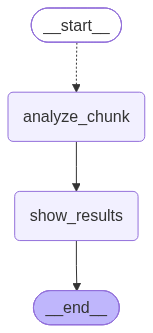

In [114]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(TenderState)

builder.add_node("analyze_chunk", analyze_chunk)
builder.add_node("show_results", show_results)

builder.add_conditional_edges(
    START,
    map_chunks,
    ["analyze_chunk"]
)

builder.add_edge(
    "analyze_chunk",
    "show_results"
)

builder.add_edge(
    "show_results",
    END
)

graph = builder.compile()

# View
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [27]:
result = graph.invoke({
    "chunks": clean_chunks,
    "findings": []
})


TOTAL FINDINGS: 108

----------------
category='submission' requirement='Les soumissions doivent être retournées à Travaux publics et Services gouvernementaux Canada, Place Bonaventure, portail Sud-Est, 800, rue de La Gauchetière Ouest, 7ième étage, Montréal (Québec) H5A 1L6. Les soumissions peuvent être transmises par télécopieur au (514) 496-3822.' status='FOUND' source_section='RETOURNER LES SOUMISSIONS À:' evidence='Travaux publics et Services gouvernementaux Canada Place Bonaventure, portail Sud-Est 800, rue de La Gauchetière Ouest 7 ième étage Montréal Québec H5A 1L6 FAX pour soumissions: (514) 496-3822'

----------------
category='submission' requirement='The bidder must submit an offer to sell the listed goods, services, and construction to Public Works and Government Services Canada at the prices set out in the tender, in accordance with the stated, referenced, or attached terms and conditions.' status='FOUND' source_section="INVITATION TO TENDER APPEL D'OFFRES" evidence='We 

Create the final schema
Now we build the tender-level Reduce step.

In [115]:
class FinalRequirementItem(BaseModel):
    requirement: str

    status: Literal[
        "FOUND",
        "NOT_REQUIRED",
        "EXTERNAL_REFERENCE",
    ]

    requirement_type: Literal[
        "MANDATORY",
        "CONDITIONAL",
        "INFORMATIONAL",
    ]

    source_sections: list[str] = Field(default_factory=list)
    evidence: list[str] = Field(default_factory=list)


class RequirementCategory(BaseModel):
    category: Literal[
        "submission",
        "required_documents",
        "certifications",
        "insurance",
        "bonding_security",
        "experience",
        "personnel",
        "technical",
        "financial",
        "formatting",
        "legal_regulatory",
        "language",
        "security",
        "site_meeting",
        "signatures",
    ]

    status: Literal[
        "FOUND",
        "NOT_FOUND",
    ]

    requirements: list[FinalRequirementItem] = Field(
        default_factory=list
    )


class TenderAnalysis(BaseModel):
    categories: list[RequirementCategory]

Update your state:

In [116]:
class TenderState(TypedDict):
    chunks: list
    findings: Annotated[list[Requirement], operator.add]
    final_analysis: TenderAnalysis

Create the Reduce LLM

In [117]:
reducer_llm = llm.with_structured_output(TenderAnalysis)

Now create the node:

In [118]:
def reduce_findings(state: TenderState):

    findings = state["findings"]

    findings_text = "\n\n".join(
        finding.model_dump_json()
        for finding in findings
    )

    prompt = f"""
You are performing the final compliance analysis of a government tender.

Multiple workers independently analyzed text sections and tables.

Consolidate their findings into ONE tender-level analysis.

Return exactly one category for each:

1. submission
2. required_documents
3. certifications
4. insurance
5. bonding_security
6. experience
7. personnel
8. technical
9. financial
10. formatting
11. legal_regulatory
12. language
13. security
14. site_meeting
15. signatures


CATEGORY STATUS:

FOUND:
At least one legitimate requirement or explicit statement
was identified for this category.

NOT_FOUND:
No legitimate requirement or explicit statement was identified
for this category anywhere in the analyzed tender.

If status is NOT_FOUND, requirements must be an empty list.


INDIVIDUAL REQUIREMENT STATUS:

FOUND:
The tender directly establishes the requirement.

NOT_REQUIRED:
The tender explicitly states that this specific requirement
does not apply or is not required.

EXTERNAL_REFERENCE:
The tender indicates that the requirement exists, but important
details are defined in another referenced clause, document,
form, standard, appendix, or source.


IMPORTANT:

A category may contain requirements with DIFFERENT statuses.

For example:

bonding_security
    Bid security must be submitted → FOUND
    Amount defined in GI09 → EXTERNAL_REFERENCE

Do not collapse those into one status.


BONDING VS SECURITY:

bonding_security means financial security such as:
- bid security
- bid bonds
- performance bonds
- labour and material payment bonds
- deposits
- contract security

security means government/personnel/facility security such as:
- security clearance
- reliability status
- protected/classified information
- personnel screening

"No security requirement" refers to the security category.
It does NOT mean that bid security or bonding is not required.


EXPERIENCE:

Only classify a finding as experience when the bidder must
demonstrate qualifications or experience, such as:
- years of experience
- similar projects
- project references
- demonstrated expertise
- required project history

General past-performance evaluation or Canada's right to reject
a bidder because of poor previous performance is NOT an
experience qualification.

Such conditions should normally be classified under
legal_regulatory.


CONSOLIDATION RULES:

- Combine duplicate findings.
- Combine evidence from text and tables when they describe the
  same requirement.
- Do not invent requirements.
- Preserve specific numbers, dates, deadlines, forms, quantities,
  insurance limits, bond requirements and submission rules.
- Preserve useful source sections.
- Prefer direct tender evidence over inference.
- Do not treat the absence of information as NOT_REQUIRED.
- NOT_REQUIRED requires an explicit statement.
- EXTERNAL_REFERENCE does not mean NOT_FOUND.


REQUIREMENT TYPE:

For every individual requirement, assign exactly one:

MANDATORY:
The bidder or contractor must, shall, is required to, or otherwise
has to satisfy the requirement.

This includes requirements where failure to comply could make the
bid non-responsive or prevent contract performance.

Examples:
- Submit the bid before the closing deadline.
- Provide bid security.
- Sign the bid.
- Maintain required insurance.
- Provide required pricing.
- Complete the work within the required period.


CONDITIONAL:
The requirement applies only if a stated condition, circumstance,
event, or trigger occurs.

Examples:
- Provide pardon documentation if applicable.
- Obtain approval if proposing alternative materials.
- Provide additional insurance coverage where the work involves
  specified hazards.
- Provide documents upon Canada's request.


INFORMATIONAL:
The statement provides context, process information, Canada's rights,
administrative information, or other information that does not itself
require the bidder to take an action to make the bid compliant.

Examples:
- Canada may reject unreasonable prices.
- Canada may cancel the solicitation.
- A public bid opening will occur after closing.
- Canada may correct arithmetic errors.


IMPORTANT:

Classify based on what the BIDDER or CONTRACTOR is required to do,
not merely because the statement uses words such as "must" or "shall."

A rule describing what Canada may or will do is generally INFORMATIONAL.

NOT_REQUIRED requirements should normally be INFORMATIONAL because
they tell the bidder that an obligation does not apply.


WORKER FINDINGS:

{findings_text}
"""

    analysis = reducer_llm.invoke(prompt)

    return {
        "final_analysis": analysis
    }

Change the graph

analyze_chunk
    ↓
reduce_findings

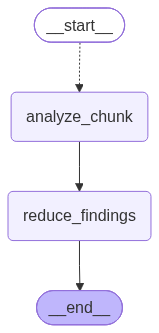

In [119]:
builder = StateGraph(TenderState)

builder.add_node(
    "analyze_chunk",
    analyze_chunk
)

builder.add_node(
    "reduce_findings",
    reduce_findings
)

builder.add_conditional_edges(
    START,
    map_chunks,
    ["analyze_chunk"]
)

builder.add_edge(
    "analyze_chunk",
    "reduce_findings"
)

builder.add_edge(
    "reduce_findings",
    END
)

graph = builder.compile()

# View
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [35]:
result = graph.invoke({
    "chunks": clean_chunks,
    "findings": []
})

                    TENDER
                       ↓
                     MAP
        ┌──────────────┼──────────────┐
        ↓              ↓              ↓
     Chunk 1         Chunk 2       Chunk N
        ↓              ↓              ↓
     Extract         Extract        Extract
        ↓              ↓              ↓
        └──────────────┼──────────────┘
                       ↓
             operator.add reducer
                       ↓
               REDUCE FINDINGS
                       ↓
        Consolidate + deduplicate
                       ↓
        Determine missing categories
                       ↓
            FINAL TENDER ANALYSIS

In [36]:
analysis = result["final_analysis"]

for category in analysis.categories:
    print("\n==============================")
    print(category.category.upper())
    print("STATUS:", category.status)

    for requirement in category.requirements:
        print("-", requirement)

    print("SOURCES:", category.source_sections)


SUBMISSION
STATUS: FOUND
- Submit the bid to Public Works and Government Services Canada at Place Bonaventure, southeast portal, 800 de La Gauchetière Street West, 7th floor, Montréal, Québec H5A 1L6.
- The solicitation closes at 02:00 PM Eastern Daylight Time on June 19, 2012.
- The bid form must identify the vendor/firm name and address, telephone number, and facsimile number; the BA02 form also requires the Procurement Business Number (PBN).
- Bids must not be transmitted by facsimile or email. Bid revisions may be submitted by letter or facsimile under GI11; revisions by facsimile must be sent to (514) 496-3822.
- Submit written enquiries only to the Contracting Officer named on the Invitation to Tender. Enquiries should be received no later than seven calendar days before closing, except for alternative-material approvals under GI16.
- Submission acknowledges that the bidder has read and agrees to the Invitation to Tender, instructions, clauses, drawings, specifications, Bid and 

Add tables to the graph state

In [120]:
class TenderState(TypedDict):
    chunks: list
    tables: list
    findings: Annotated[list[Requirement], operator.add]
    final_analysis: TenderAnalysis

And create a worker state for tables:

In [121]:
class TableWorkerState(TypedDict):
    table_number: int
    table_data: str

Get the tables from Docling

In [ ]:
%whos

In [ ]:
docling_result = converter.convert("tender.PDF")

Now convert the tables already inside result.document:
We're using Markdown here only as a convenient way of giving the LLM the DataFrame's row/column structure.

In [66]:
tables = []

for i, table in enumerate(docling_result.document.tables):

    df = table.export_to_dataframe(
        doc=docling_result.document
    )

    tables.append({
        "table_number": i + 1,
        "table_data": df.to_markdown(index=False)
    })

print("Tables:", len(tables))

Tables: 5


Create the table worker
The table worker can use the same ChunkFindings structured output as your text worker.

In [122]:
def analyze_table(state: TableWorkerState):

    table_number = state["table_number"]
    table_data = state["table_data"]

    prompt = f"""
You are analyzing a table extracted from a government tender.

Extract ONLY tender requirements explicitly supported by this table.

Categories:
- submission
- required_documents
- certifications
- insurance
- bonding_security
- experience
- personnel
- technical
- financial
- formatting
- legal_regulatory
- language
- security
- site_meeting
- signatures

Status rules:

FOUND:
The table contains or establishes a requirement.

NOT_REQUIRED:
The table explicitly states that something is not required.

EXTERNAL_REFERENCE:
The table references another document, form, clause,
standard, appendix, or source that defines the requirement.

Important:
- Do not return NOT_FOUND.
- Do not invent requirements.
- Preserve quantities, units, prices, specification references,
  forms, dates, limits, and other concrete details.
- If the table contains no relevant requirements, return an empty list.

IMPORTANT CATEGORY DISTINCTIONS:

bonding_security:
Financial security associated with the bid or contract, such as:
- bid bonds
- bid security
- performance bonds
- labour and material payment bonds
- deposits
- contract security

security:
Personnel, organization, facility, or government security requirements,
such as:
- security clearances
- reliability status
- protected/classified information
- site security screening

Never classify "no security requirement" as bonding_security.

EXPERIENCE RULE:

Classify something as "experience" only when the bidder is required
to demonstrate qualifications or experience, such as:

- minimum years of experience
- previous similar projects
- project references
- demonstrated expertise
- required past project history

Do NOT classify general past-performance evaluation or Canada's
right to reject a bidder for poor previous performance as an
experience requirement.

Those conditions belong under legal_regulatory unless the tender
explicitly requires the bidder to demonstrate experience.

For source_section use:
"Table {table_number}"

TABLE:

{table_data}
"""

    result = extractor.invoke(prompt)

    return {
        "findings": result.requirements
    }

In [123]:
extractor = llm.with_structured_output(ChunkFindings)

So both paths produce:

Text Worker  → list[Requirement]
Table Worker → list[Requirement]

Create the table Map

In [124]:
def map_tables(state: TenderState):

    return [
        Send(
            "analyze_table",
            {
                "table_number": table["table_number"],
                "table_data": table["table_data"]
            }
        )
        for table in state["tables"]
    ]

                    START
                 /         \
                /           \
         map_chunks       map_tables
             ↓                ↓
        text workers      table workers
             \                /
              \              /
               ↓            ↓
                  findings

In [137]:
def generate_report(state: TenderState):

    analysis = state["final_analysis"]

    analysis_json = analysis.model_dump_json(
        indent=2
    )

    prompt = f"""
You are assisting a proposal team reviewing a government tender.

You have been given a structured analysis of the tender.

Your job is to create a decision-support report that helps a HUMAN
decide whether the company should bid.

You must NOT make the bid/no-bid decision.

Do NOT say:
- BID
- NO BID
- We recommend bidding
- We recommend not bidding

Instead, organize the available evidence so the human can make
the decision.


EXECUTIVE SUMMARY

Provide a concise overview of the opportunity and the most important
requirements, risks, constraints, and unresolved issues.


REASONS TO CONSIDER BIDDING

Identify characteristics of the tender that may make the opportunity
worth considering.

Only use evidence available in the tender analysis.

Do not assume anything about the bidder's capabilities.


CONCERNS AND RISKS

Identify requirements or conditions that could create difficulty,
cost, compliance risk, scheduling risk, contractual risk, or
submission risk.

Examples include:
- tight deadlines
- bonding
- insurance
- unusual technical requirements
- strict submission rules
- significant contractual obligations


MISSING INFORMATION

Identify information required for evaluating the opportunity that
cannot be determined from the tender analysis.

Also include important requirements whose details are contained in
external references that still need to be reviewed.


MANDATORY REQUIREMENTS

Summarize the most important mandatory requirements that could affect
the decision to pursue the opportunity.

Do not simply repeat every extracted requirement. Prioritize those
that materially affect eligibility, compliance, cost, schedule,
technical delivery, or submission.


CONDITIONAL REQUIREMENTS

Identify important requirements that become applicable only under
specific circumstances.


EXTERNAL REFERENCES TO REVIEW

Identify referenced clauses, forms, standards, drawings,
specifications, or other documents that should be reviewed before
making the bid/no-bid decision.


QUESTIONS FOR THE BID TEAM

Generate practical questions the human team should answer before
making a decision.

Examples:

- Can we meet the required construction schedule?
- Can we obtain the required bonding?
- Do our insurance limits satisfy the requirement?
- Do we have the resources and capacity to perform the work?
- Have all external specifications and drawings been reviewed?
- Can we price the required scope competitively?

Do not assume the answers.


IMPORTANT RULES

- Base the report only on the supplied tender analysis.
- Do not invent company capabilities.
- Do not invent tender requirements.
- Clearly identify uncertainty.
- Treat EXTERNAL_REFERENCE findings as unresolved until reviewed.
- Treat NOT_FOUND as absence of extracted evidence, not proof that
  the tender has no such requirement.
- Do not make the final bid/no-bid decision.
- The final decision belongs to the human proposal team.


TENDER ANALYSIS:

{analysis_json}
"""

    report = report_llm.invoke(prompt)

    return {
        "decision_report": report
    }

Update the graph

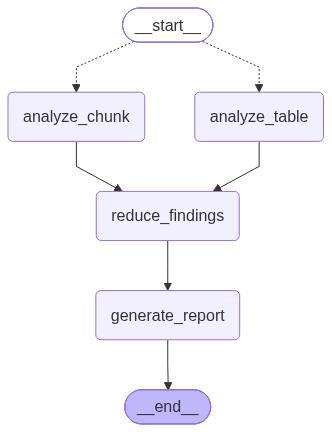

In [138]:
builder = StateGraph(TenderState)

builder.add_node(
    "analyze_chunk",
    analyze_chunk
)

builder.add_node(
    "analyze_table",
    analyze_table
)

builder.add_node(
    "reduce_findings",
    reduce_findings
)

builder.add_node(
    "generate_report",
    generate_report
)

builder.add_conditional_edges(
    START,
    map_chunks,
    ["analyze_chunk"]
)

builder.add_conditional_edges(
    START,
    map_tables,
    ["analyze_table"]
)

builder.add_edge(
    "analyze_chunk",
    "reduce_findings"
)

builder.add_edge(
    "analyze_table",
    "reduce_findings"
)

builder.add_edge(
    "reduce_findings",
    "generate_report"
)

builder.add_edge(
    "generate_report",
    END
)

graph = builder.compile()

# View
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [126]:
final_result = graph.invoke({
    "chunks": clean_chunks,
    "tables": tables,
    "findings": []
})

In [131]:
analysis = final_result["final_analysis"]

for category in analysis.categories:

    print("\n==============================")
    print(category.category.upper())
    print("CATEGORY STATUS:", category.status)

    for item in category.requirements:

        print(f"\n- {item.requirement}")
        print("  STATUS:", item.status)
        print("  TYPE:", item.requirement_type)

        if item.source_sections:
            print("  SOURCES:", item.source_sections)


SUBMISSION
CATEGORY STATUS: FOUND

- Submit the bid to Public Works and Government Services Canada at Place Bonaventure, South-East Portal, 800 de La Gauchetière West Street, 7th Floor, Montréal, Québec H5A 1L6; the bid fax number is (514) 496-3822.
  STATUS: FOUND
  TYPE: MANDATORY
  SOURCES: ['RETOURNER LES SOUMISSIONS À: / Invitation to Tender']

- Provide the bidder's business or firm name and address, together with telephone number, fax number and Procurement Business Number in BA02.
  STATUS: FOUND
  TYPE: MANDATORY
  SOURCES: ['Invitation to Tender', 'BA02 BUSINESS NAME AND ADDRESS OF BIDDER']

- Submit an offer covering the listed goods, services and construction at the prices stated in the tender and attached sheets.
  STATUS: FOUND
  TYPE: MANDATORY
  SOURCES: ['Invitation to Tender']

- Submit the bid no later than June 19, 2012 at 2:00 p.m. Eastern Daylight Time.
  STATUS: FOUND
  TYPE: MANDATORY
  SOURCES: ['Issuing Office - Bureau de distribution']

- Comply with the bid

                         PDF
                          ↓
                       DOCLING
                          ↓
              ┌───────────┴───────────┐
              ↓                       ↓
           Markdown                  Tables
              ↓                       ↓
       Heading splitter            DataFrames
              ↓                       ↓
         clean_chunks               tables
              ↓                       ↓
          MAP chunks              MAP tables
              ↓                       ↓
       analyze_chunk            analyze_table
              ↓                       ↓
              └───────────┬───────────┘
                          ↓
                       findings
                          ↓
                  operator.add
                          ↓
                  REDUCE FINDINGS
                          ↓
             Consolidate + deduplicate
                          ↓
                15 requirement areas
                          ↓
                TenderAnalysis JSON

In [129]:
item = final_result["final_analysis"].categories[0].requirements[0]

print("Current class fields:")
print(FinalRequirementItem.model_fields.keys())

print("\nObject's class fields:")
print(type(item).model_fields.keys())

print("\nSame class?")
print(type(item) is FinalRequirementItem)

Current class fields:
dict_keys(['requirement', 'status', 'requirement_type', 'source_sections', 'evidence'])

Object's class fields:
dict_keys(['requirement', 'status', 'requirement_type', 'source_sections', 'evidence'])

Same class?
True


Decision Support Report node

In [132]:
class DecisionSupportReport(BaseModel):
    executive_summary: str

    reasons_to_consider_bidding: list[str] = Field(
        default_factory=list
    )

    concerns_and_risks: list[str] = Field(
        default_factory=list
    )

    missing_information: list[str] = Field(
        default_factory=list
    )

    mandatory_requirements: list[str] = Field(
        default_factory=list
    )

    conditional_requirements: list[str] = Field(
        default_factory=list
    )

    external_references_to_review: list[str] = Field(
        default_factory=list
    )

    questions_for_bid_team: list[str] = Field(
        default_factory=list
    )

In [133]:
class TenderState(TypedDict):
    chunks: list
    tables: list
    findings: Annotated[list[Requirement], operator.add]

    final_analysis: TenderAnalysis
    decision_report: DecisionSupportReport

In [134]:
report_llm = llm.with_structured_output(
    DecisionSupportReport
)

In [139]:
final_result = graph.invoke({
    "chunks": clean_chunks,
    "tables": tables,
    "findings": []
})

In [ ]:
analysis = final_result["final_analysis"]
report = final_result["decision_report"]

# Analysis

In [ ]:
from IPython.display import display, Markdown

analysis = final_result["final_analysis"]

md = "# Tender Analysis\n"

for category in analysis.categories:

    md += f"\n## {category.category.replace('_', ' ').title()}\n"
    md += f"**Category Status:** `{category.status}`\n"

    if not category.requirements:
        md += "\n_No requirements found._\n"
        continue

    for item in category.requirements:

        md += f"\n### {item.requirement}\n"
        md += f"- **Status:** `{item.status}`\n"
        md += f"- **Type:** `{item.requirement_type}`\n"

        if item.source_sections:
            md += f"- **Sources:** {', '.join(item.source_sections)}\n"

display(Markdown(md))

# Report

In [142]:
report = final_result["decision_report"]

md = "# Bid / No-Bid Decision Support Report\n"

md += f"""
## Executive Summary

{report.executive_summary}

## Reasons to Consider Bidding
"""

for x in report.reasons_to_consider_bidding:
    md += f"- {x}\n"

md += "\n## Concerns and Risks\n"

for x in report.concerns_and_risks:
    md += f"- {x}\n"

md += "\n## Missing Information\n"

for x in report.missing_information:
    md += f"- {x}\n"

md += "\n## Mandatory Requirements\n"

for x in report.mandatory_requirements:
    md += f"- {x}\n"

md += "\n## Conditional Requirements\n"

for x in report.conditional_requirements:
    md += f"- {x}\n"

md += "\n## External References to Review\n"

for x in report.external_references_to_review:
    md += f"- {x}\n"

md += "\n## Questions for the Bid Team\n"

for x in report.questions_for_bid_team:
    md += f"- {x}\n"

display(Markdown(md))

# Bid / No-Bid Decision Support Report

## Executive Summary

This is a Public Works and Government Services Canada construction opportunity for resurfacing and related work at the Laval Complex – Personnel College. The work includes traffic control and site protection, earthwork, excavation and disposal, drainage, retaining-wall, concrete, pavement, lighting, landscaping, tank-related and related construction activities. Completion is required within seven weeks after notification of acceptance. The submission deadline identified in the analysis was June 19, 2012 at 2:00 p.m. Eastern Daylight Time. Material compliance considerations include bid security, contract security, substantial insurance limits and extended completed-operations coverage, detailed unit-price schedules, mandatory certifications, strict submission and communication procedures, and review of numerous incorporated clauses, specifications, drawings, and wage requirements. Key unresolved matters include the detailed requirements in GI08–GI11, GI03–GI05, GI14–GI18, SC02–SC03, GC9, R2890D, and the referenced technical specifications and drawings.

## Reasons to Consider Bidding
- The opportunity has a defined construction scope, work schedules, quantities, units, and specification references, which may support preparation of a detailed estimate.
- The project does not require a site visit according to SI03.
- The tender analysis states that no government, personnel, facility, or information security requirement applies to the project.
- The work is subject to a defined seven-week completion period, allowing the proposal team to assess the opportunity against a specific delivery timeframe.
- The pricing structure includes unit prices and estimated totals for scheduled work items, with unit prices governing the total extended amount.
- The contract documents and submission forms identify the project location, work categories, pricing fields, and required completion commitment.

## Concerns and Risks
- The stated closing date was June 19, 2012 at 2:00 p.m. Eastern Daylight Time. This date is historical and must be confirmed against the authoritative tender documents before any action is taken.
- The required completion period is seven weeks from notification of acceptance, creating potential scheduling, mobilization, procurement, labour, subcontractor, and coordination pressure.
- Bid security is mandatory, but the amount, acceptable form, validity, and detailed conditions are contained in GI09 and have not been resolved from the analysis.
- Contract security is required under GC9/R2890D, but the applicable security type, amount, timing, and issuance conditions require review.
- Insurance obligations are substantial: at least $5,000,000 per occurrence, $5,000,000 products/completed-operations aggregate, and, where applicable, $10,000,000 general aggregate coverage. Coverage must continue through completion, with completed-operations liability maintained for at least six years after the Certificate of Substantial Performance.
- The contractor bears payments up to the deductible, and insurance must include Canada as an additional insured and provide at least 30 days' advance notice of cancellation or reduction.
- The work may involve hazardous or specialized exposures, including blasting, pile driving or caisson work, underpinning, and removal or weakening of building or land support. Applicable endorsements must be confirmed if those activities are within scope.
- The scope spans multiple civil, structural, drainage, concrete, pavement, electrical, lighting, landscaping, and tank-related activities. The detailed technical specifications and drawings have not been reviewed in the supplied analysis.
- The bid must include detailed unit prices and estimated totals across Tables 3–5, with arithmetic accuracy and consistency important because Canada may correct arithmetic errors and reject prices that do not reasonably reflect the applicable work.
- The bid submission process is strict: communications must be directed only to the named Contracting Officer, bids cannot be transmitted by fax or email, and submission and revision procedures are incorporated through GI10 and GI11.
- The submission acknowledges agreement to the Invitation to Tender, instructions, clauses, drawings, specifications, appendices, and pre-closing amendments, increasing the consequence of incomplete document review.
- The bidder must remain free of specified charges and convictions during the contract period, and the certifications extend to parent companies, subsidiaries, and affiliates.
- Canada reserves broad rights to reject bids for matters including ineligibility, bankruptcy, fraud, bribery, misrepresentation, poor performance, default, process-integrity concerns, or value concerns.

## Missing Information
- The analysis does not establish whether the stated 2012 closing date remains current, whether amendments were issued, or whether the opportunity is still open.
- The amount and precise form of required bid security are not stated; GI09 must be reviewed.
- The type, amount, timing, and conditions of contract security under GC9/R2890D are not stated.
- The full insurance requirements in SC02, GC10/R2900D, and IBC Form 2100, as amended, have not been reviewed.
- The analysis does not identify the named Contracting Officer's contact details beyond the requirement to communicate only with that officer.
- The detailed contents of GI10 submission procedures and GI11 revision procedures are unresolved.
- The subcontractor and supplier listing requirements under GI08 are unresolved.
- The analysis does not identify bidder eligibility, tax, legal-capacity, conflict-of-interest, unfair-advantage, or Procurement Business Number details contained in GI03–GI05 and GI14–GI18.
- The analysis does not provide the detailed technical requirements, drawings, site conditions, existing-utility information, phasing constraints, access restrictions, or acceptance criteria for the work.
- Experience, personnel, and resource requirements were not found in the extracted analysis; this does not establish that none exist in the full tender documents.
- The analysis does not identify the project insurance deductibles, policy exclusions, required endorsements beyond those summarized, or the cost and availability of the required coverage.
- The analysis does not state the required bid security and contract security expiry periods or the time allowed to provide post-award documents.
- The analysis does not establish applicable wage rates, labour-hour restrictions, or detailed fair-wage obligations contained in R2940D and the Schedules of Wage Rates.
- The analysis does not identify the applicable payment terms, schedule of quantities reconciliation rules, change-order provisions, delay provisions, liquidated damages, warranty obligations, or termination provisions in the full contract documents.
- The analysis contains a potential ambiguity between the statement that no security requirement applies and the separate reference to SC01; the authoritative tender wording should be confirmed.

## Mandatory Requirements
- Submit the completed Bid and Acceptance Form, applicable appendices, required identification information, authorized signature, title, and signature date.
- Submit the offer to the specified PWGSC location by the stated closing deadline, using an accepted delivery method. Do not transmit the bid by fax or email.
- Follow GI10 for submission and GI11 for revisions after reviewing those incorporated provisions.
- Direct solicitation-period communications only to the named Contracting Officer. Normally submit enquiries at least seven calendar days before closing.
- Maintain the bid for 30 days after closing and comply with BA04 and SI07 regarding validity.
- Enclose bid security in accordance with GI09 and satisfy contract security requirements under GC9/R2890D.
- Provide bidder name, address, telephone, fax, PBN, total amount excluding GST/HST, and all required unit and estimated total prices.
- Transfer the required total estimated amount to SA03 as directed by the pricing documents.
- Complete the listed resurfacing and related construction work in accordance with the Bid Documents, drawings, specifications, and applicable technical sections.
- Complete the work within seven weeks after notification of acceptance.
- Maintain the required insurance limits, name Canada as an additional insured, provide the required certificate of insurance, and maintain coverage for the specified periods.
- Comply with the Code of Conduct and Certifications, including certifications concerning the bidder and relevant parent, subsidiary, and affiliate entities.
- Comply with applicable laws, fair-wage and labour requirements, legal-capacity and tax requirements, conflict-of-interest and unfair-advantage provisions, and other incorporated general instructions.
- Use the language of the submitted Bid and Acceptance Form for the contract documents.
- Acknowledge and accept the binding effect of the identified invitation, instructions, clauses, drawings, specifications, appendices, amendments, and other contract documents.

## Conditional Requirements
- Submit certified leniency or criminal-pardon documentation if the bidder or an affiliate has pleaded guilty to a specified offence and the stated exception applies.
- Provide original or certified true copies of insurance contracts if Canada requests them.
- Include insurance endorsements for blasting, pile driving or caisson work, underpinning, or removal or weakening of building or land support when the work is subject to those hazards.
- Provide written acceptance if Canada requests an extension of bid validity and the bidder elects to accept it.
- Submit solicitation enquiries at least seven calendar days before closing, except where the GI16 alternative-material process provides otherwise.
- Apply the SC01 security-access provisions if they become applicable, notwithstanding the analysis statement that the project has no security requirement.
- Provide pardon or leniency documentation and maintain continuing compliance if the relevant charges, convictions, or affiliate circumstances exist.
- Follow the special revision process if a bid revision is required; facsimile revisions must use the specified fax number, while the original bid itself cannot be transmitted by fax or email.
- Apply the $10,000,000 general aggregate insurance limit where the applicable policy or work circumstances require it.

## External References to Review
- GI03–GI05 and GI14–GI18: bidder eligibility, legal capacity, tax, PBN, applicable-law, conflict-of-interest, unfair-advantage, and related general requirements.
- GI08: mandatory listing of subcontractors and suppliers.
- GI09: bid security amount, form, timing, validity, and enforcement provisions.
- GI10 and GI11: detailed bid submission and revision procedures.
- SI04: revision procedures and any interaction with GI11.
- SC02, GC10, and R2900D: complete insurance requirements, endorsements, deductibles, policy terms, and proof requirements.
- IBC Form 2100, as amended: minimum coverage benchmark referenced by the insurance provisions.
- GC9 and R2890D: contract security requirements.
- GI15, R2940D, and the applicable Schedules of Wage Rates: laws, labour conditions, fair wages, and wage rates.
- All drawings and specifications referenced in Tables 3–5, including specification sections 01 35 00.06, 01 52 00, 31 00 00.01, 32 12 16, 33 41 00, the 26 05 00 series, and all other cited sections.
- Appendix 1, SA03, and the complete Tables 1, 3, 4, and 5: pricing structure, transfer requirements, units, quantities, and governing-price rules.
- SC03 and SI11: complete Code of Conduct and Certifications provisions, including affiliate checks and continuing obligations.
- SC01: security-access provisions, to resolve the apparent relationship with the statement that no security requirement applies.
- The Invitation to Tender, all pre-closing amendments, and the complete Contract Documents list, including dates and referenced versions.

## Questions for the Bid Team
- Is the June 19, 2012 closing date current, and have the authoritative tender documents and all amendments been obtained?
- Can the proposed delivery team complete the full scope within seven weeks from notification of acceptance?
- Can the company mobilize the required civil, concrete, drainage, pavement, electrical, lighting, landscaping, and related resources concurrently or in the required sequence?
- Can the company obtain bid security in the required form and amount under GI09?
- Can the company obtain and maintain the required contract security under GC9/R2890D?
- Do available insurance policies or insurers satisfy the stated limits, additional-insured requirement, endorsements, notice period, deductibles, and six-year completed-operations obligation?
- What are the likely insurance and bonding costs, and have they been included in the pricing model?
- Have all drawings, specifications, amendments, and referenced technical sections been reviewed by qualified technical personnel?
- Are the quantities, units, work-item descriptions, and specification references in Tables 3–5 sufficiently clear to price accurately?
- Can the required unit prices, extended amounts, total estimated amounts, and SA03 transfer be completed without arithmetic or form-completion errors?
- Are all required subcontractors and suppliers identified in accordance with GI08, and are their quotations and availability confirmed?
- Can the company meet the applicable wage rates, labour conditions, statutory requirements, and any site-hour or access constraints?
- Have potential hazardous-work exposures such as blasting, underpinning, pile driving, caisson work, or support removal been identified and priced with appropriate insurance and safety controls?
- Has the team confirmed the named Contracting Officer and established a compliant process for all questions and any permitted revisions?
- Has the team reviewed GI10 and GI11 sufficiently to ensure the physical submission, packaging, delivery, and revision process will be compliant?
- Do the bidder and all relevant parent, subsidiary, and affiliate entities satisfy the Code of Conduct and certification requirements?
- Are any pardon, leniency, criminal-history, conflict-of-interest, tax, legal-capacity, or unfair-advantage issues relevant to the bidder or its affiliates?
- What are the contractual provisions governing payment, changes, delays, damages, warranties, completion, and termination, and have their commercial effects been assessed?
- Does the absence of extracted experience and personnel requirements reflect the full tender, or do the external documents contain additional qualification requirements?
- Has the apparent inconsistency between the no-security statement and SC01 been clarified from the authoritative tender documents?
- Can the complete scope be priced competitively while allowing for the seven-week schedule, insurance, security, labour, subcontractor, and contingency costs?
